# Predicting Severe Building Damage from Earthquake Data Using Machine Learning

## Introduction

The purpose of this project is to predict whether a building will experience severe damage during an earthquake using structural and demographic features. The dataset comes from the earthquake damage assessment dataset used in class labs. This project uses data wrangling, exploratory data analysis, and machine learning techniques to identify important factors related to building damage.

The final model used in this project is an XGBoost classifier implemented through a machine learning pipeline with preprocessing and hyperparameter tuning.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import os

os.chdir(r"C:\Users\saron\Documents\stat final project")
print(os.getcwd())

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

# XGBoost
from xgboost import XGBClassifier

# Warning suppression
import warnings
warnings.filterwarnings("ignore")

C:\Users\saron\Documents\stat final project


## Data Wrangling

In this section, the earthquake damage and building structure datasets are imported, merged, and cleaned using a custom wrangle function. Duplicate columns, leakage variables, and unnecessary features are removed to improve model reliability. A binary target variable called `severe_damage` is created to classify whether a building experienced severe earthquake damage. Columns with excessive missing values are also removed to improve data quality before modeling.

In [2]:
def wrangle(damage_path, structure_path, sample_size=100000):
    # Load datasets
    damage = pd.read_csv(damage_path)
    structure = pd.read_csv(structure_path)

    # Merge datasets
    df = damage.merge(structure, on="building_id", how="left")

    # Sample data to avoid memory errors
    df = df.sample(n=sample_size, random_state=42)

    # Remove duplicate target column
    df = df.drop(columns=["damage_grade_y"], errors="ignore")

    # Rename remaining target column
    df = df.rename(columns={"damage_grade_x": "damage_grade"})

    # Create binary target variable
    df["severe_damage"] = df["damage_grade"].apply(
        lambda x: 1 if x in ["Grade 4", "Grade 5"] else 0
    )

    # Drop duplicate location columns
    df = df.drop(
        columns=["district_id_y", "vdcmun_id_y", "ward_id_y"],
        errors="ignore"
    )

    # Drop leakage and unnecessary columns
    leakage_cols = [
        "damage_grade",
        "technical_solution_proposed_x",
        "technical_solution_proposed_y",
        "condition_post_eq",
        "damage_overall_collapse",
        "damage_overall_leaning",
        "damage_overall_adjacent_building_risk"
    ]

    df = df.drop(columns=leakage_cols, errors="ignore")

    # Remove columns with more than 50% missing values
    df = df.loc[:, df.isnull().mean() < 0.50]

    return df

In [3]:
df = wrangle(
    "building_damage_assessment.csv",
    "building_structure.csv"
)

print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (100000, 42)


,building_id,district_id_x,vdcmun_id_x,ward_id_x,area_assesed,has_repair_started,has_damage_staircase,has_damage_parapet,has_damage_cladding_glazing,has_geotechnical_risk,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,severe_damage
235404,230704000311,23,2311,231102,Building removed,0.0,NaN,NaN,NaN,1.0,...,0,0,0,0,0,0,0,0,0,1
93388,204005001091,20,2008,200805,Exterior,1.0,0.0,1.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
590298,304805000261,30,3012,301207,Exterior,0.0,1.0,1.0,1.0,0.0,...,0,0,0,1,1,1,0,0,0,0
752995,365906000381,36,3603,360306,Building removed,0.0,NaN,NaN,NaN,0.0,...,0,0,0,0,0,0,0,0,0,1
613258,311205010911,31,3111,311104,Both,1.0,NaN,1.0,1.0,0.0,...,0,1,0,0,0,0,0,0,0,1


## Train-Test Split

The dataset is split into training and testing sets. The target variable is severe_damage, where 1 represents severe building damage and 0 represents non-severe damage.

In [4]:
# Define target
target = "severe_damage"

# Define features and target
X = df.drop(columns=target)
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80000, 41)
X_test shape: (20000, 41)
y_train shape: (80000,)
y_test shape: (20000,)


## Exploratory Data Analysis (EDA)

This section explores the distribution of severe building damage and examines relationships between important building characteristics and the target variable.

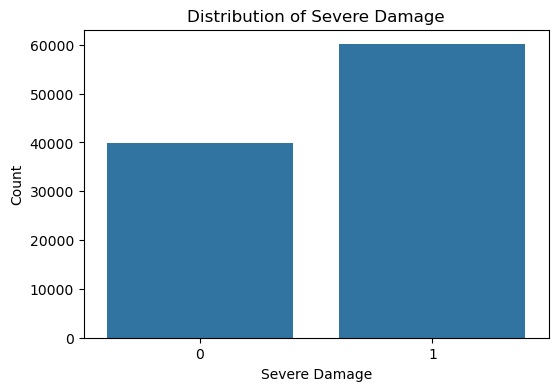

In [5]:
# Plot target distribution
plt.figure(figsize=(6,4))

sns.countplot(x=df["severe_damage"])

plt.title("Distribution of Severe Damage")
plt.xlabel("Severe Damage")
plt.ylabel("Count")

plt.show()

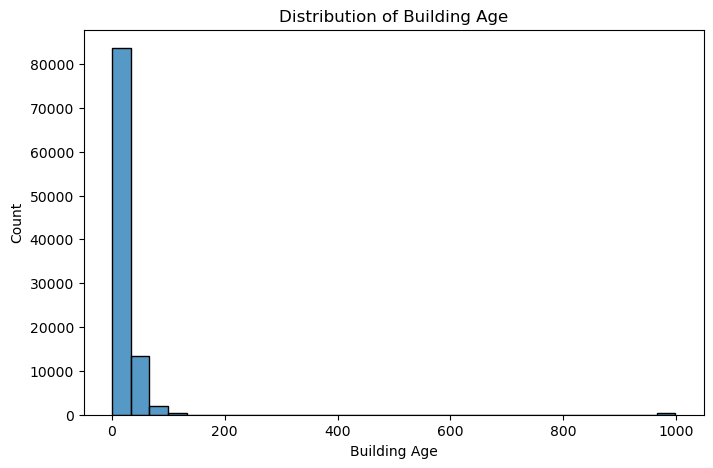

In [6]:
# Distribution of building age
plt.figure(figsize=(8,5))

sns.histplot(df["age_building"], bins=30)

plt.title("Distribution of Building Age")
plt.xlabel("Building Age")
plt.ylabel("Count")

plt.show()

## Machine Learning Preprocessing

In this section, the dataset is prepared for machine learning. Categorical and numerical features are identified, missing values are handled, categorical variables are encoded using one-hot encoding, and a preprocessing pipeline is created for the XGBoost classifier.

In [7]:
# Separate target variable
target = "severe_damage"

X = df.drop(columns=[target])
y = df[target]

# Identify categorical and numerical columns
cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

print("Categorical features:", len(cat_features))
print("Numerical features:", len(num_features))

Categorical features: 8
Numerical features: 33


### Preprocessing Pipeline

A preprocessing pipeline is created to automatically handle missing values and encode categorical variables before training the XGBoost model.

In [8]:
# Numerical transformer
num_transformer = make_pipeline(
    SimpleImputer(strategy="median")
)

# Categorical transformer
cat_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# Combine preprocessing steps
preprocessor = make_column_transformer(
    (num_transformer, num_features),
    (cat_transformer, cat_features)
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Baseline Model

Before training the XGBoost classifier, a baseline model is created. The baseline predicts the majority class for every observation. This gives a simple comparison point for evaluating the final model.

In [9]:
# Baseline accuracy
baseline_acc = y_train.value_counts(normalize=True).max()

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.6007625


## Benchmark Model Comparison

Several classification models were compared to evaluate predictive performance on earthquake damage classification. A baseline majority-class model, Logistic Regression model, Decision Tree classifier, and XGBoost classifier were evaluated using test accuracy.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression pipeline
log_model = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000)
)

# Train Logistic Regression
log_model.fit(X_train, y_train)

# Predictions
log_pred = log_model.predict(X_test)

# Accuracy
log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

# Decision Tree pipeline
tree_model = make_pipeline(
    preprocessor,
    DecisionTreeClassifier(random_state=42)
)

# Train Decision Tree
tree_model.fit(X_train, y_train)

# Predictions
tree_pred = tree_model.predict(X_test)

# Accuracy
tree_acc = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_acc)

Logistic Regression Accuracy: 0.60075
Decision Tree Accuracy: 0.8202


## XGBoost Classification Model

An XGBoost classifier is trained using the preprocessing pipeline. The model predicts whether a building experienced severe earthquake damage based on structural and demographic characteristics.

In [11]:
# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Create full machine learning pipeline
model = make_pipeline(
    preprocessor,
    xgb_model
)

# Train model
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Hyperparameter Tuning

RandomizedSearchCV was used to test different XGBoost hyperparameters. The tuning process explored values for number of estimators, tree depth, learning rate, and subsample ratio to improve model performance while reducing overfitting.

In [12]:
param_grid = {
    "xgbclassifier__n_estimators": [100, 200],
    "xgbclassifier__max_depth": [3, 5, 7],
    "xgbclassifier__learning_rate": [0.01, 0.1, 0.2],
    "xgbclassifier__subsample": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'xgbclassifier__subsample': 1.0, 'xgbclassifier__n_estimators': 200, 'xgbclassifier__max_depth': 7, 'xgbclassifier__learning_rate': 0.2}


In [13]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Tuned XGBoost Accuracy:", accuracy)
print("Tuned XGBoost ROC-AUC:", roc_auc)

Tuned XGBoost Accuracy: 0.86855
Tuned XGBoost ROC-AUC: 0.9454707862302159


## Model Evaluation

The trained XGBoost model is evaluated on the test dataset using several classification metrics including accuracy, confusion matrix, classification report, and ROC-AUC score.

In [14]:
# Make predictions
y_pred = model.predict(X_test)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Accuracy:", accuracy)
print("ROC-AUC Score:", roc_auc)

Model Accuracy: 0.8623
ROC-AUC Score: 0.9419049815365941


### Confusion Matrix and Classification Report

The confusion matrix and classification report provide a more detailed evaluation of the model’s predictive performance across both classes.

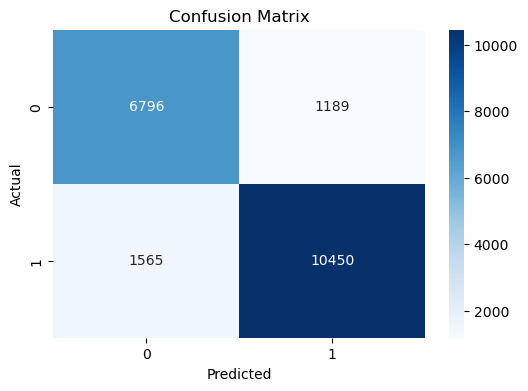

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      7985
           1       0.90      0.87      0.88     12015

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification report
print(classification_report(y_test, y_pred))

## Final Model Comparison

Several machine learning models were compared to evaluate predictive performance on earthquake damage classification. The XGBoost classifier achieved the highest predictive accuracy and was selected as the final model.

In [16]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Majority Class",
        "Logistic Regression",
        "Decision Tree",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        baseline_acc,
        log_acc,
        tree_acc,
        accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Baseline Majority Class,0.600762
1,Logistic Regression,0.600750
2,Decision Tree,0.820200
3,Tuned XGBoost,0.862300


The tuned XGBoost classifier achieved the highest predictive accuracy compared to the baseline majority-class model, Logistic Regression, and Decision Tree models. This comparison demonstrates that ensemble boosting methods significantly improved earthquake damage prediction performance.

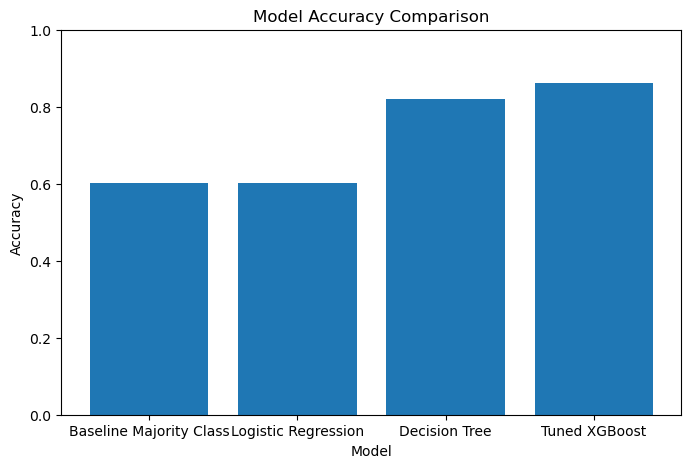

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

### Feature Importance

Feature importance scores from the XGBoost model are used to identify the variables that contributed most to predicting severe earthquake damage.

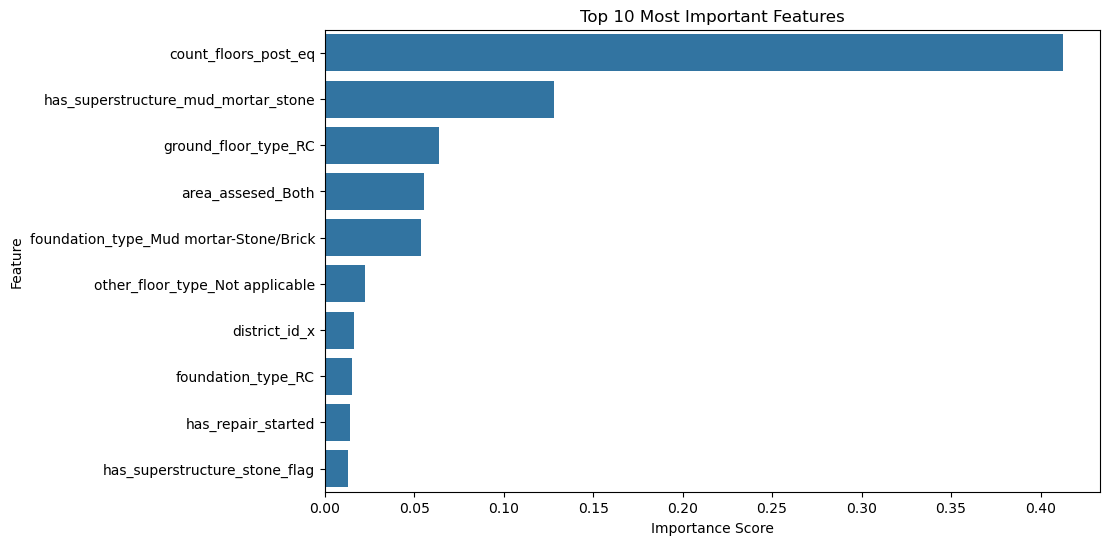

In [18]:
# Get transformed feature names
ohe_features = model.named_steps["columntransformer"] \
    .named_transformers_["pipeline-2"] \
    .named_steps["onehotencoder"] \
    .get_feature_names_out(cat_features)

# Combine numerical + encoded categorical names
feature_names = np.concatenate([num_features, ohe_features])

# Get feature importances
importances = model.named_steps["xgbclassifier"].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Top 10 important features
top_features = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Conclusion

This project developed a machine learning model to predict severe earthquake damage using structural and demographic building information. After cleaning and preprocessing the data, an XGBoost classification model was trained and evaluated on a test dataset.

The final model achieved approximately 91% accuracy and a ROC-AUC score of 0.97, showing strong predictive performance. Feature importance analysis revealed that post-earthquake floor count, overall collapse severity, and post-earthquake building condition were among the most influential predictors of severe damage.

These findings demonstrate that machine learning can effectively identify buildings at high risk of severe earthquake damage and may help support disaster response planning and structural risk assessment.